In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.models.catboost_train import train_catboost
# CHANGED: Use sklearn metrics directly
import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from src.eval.evaluate import print_metrics_summary
from src.eval.calibration import fit_calibrator_from_df
from src.features.extract import load_feature_config, extract_features_from_flows
from sklearn.model_selection import GroupShuffleSplit

paths = load_paths()
logger = setup_logger(level="INFO")

features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

logger.info("Loading VNAT features...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat"

vnat_old_path = paths.data_processed / "vnat" / "features_trainable.parquet"
if vnat_old_path.exists():
    vnat_old = pd.read_parquet(vnat_old_path)
    split_map = dict(zip(vnat_old["capture_id"], vnat_old["split"]))
    vnat_feats["split"] = vnat_feats["capture_id"].map(split_map).fillna("unknown")
else:
    logger.warning(f"Old features file not found: {vnat_old_path}. Setting splits to 'unknown'.")
    vnat_feats["split"] = "unknown"

if (vnat_feats["split"] != "unknown").any():
    vnat_feats = vnat_feats[vnat_feats["split"] != "unknown"].copy()

if "q_min_packets_ok" in vnat_feats.columns:
    vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()

logger.info("Loading ISCX features...")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

iscx_old_path = paths.data_processed / "iscx" / "features.parquet"
if iscx_old_path.exists():
    iscx_old = pd.read_parquet(iscx_old_path)
    split_map_iscx = dict(zip(iscx_old["capture_id"], iscx_old["split"]))
    iscx_feats["split"] = iscx_feats["capture_id"].map(split_map_iscx).fillna("unknown")
else:
    logger.warning(f"Old features file not found: {iscx_old_path}. Setting splits to 'unknown'.")
    iscx_feats["split"] = "unknown"

if (iscx_feats["split"] != "unknown").any():
    iscx_feats = iscx_feats[iscx_feats["split"] != "unknown"].copy()

if "q_min_packets_ok" in iscx_feats.columns:
    iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()

df_all = pd.concat([vnat_feats, iscx_feats], ignore_index=True)
df_all["split"] = df_all["split"].replace({"iscx_train": "train", "iscx_val": "val", "iscx_test": "test"})

# Rebalance VNAT
logger.info("Rebalancing VNAT splits...")
vnat_mask = df_all["dataset"] == "vnat"
vnat_df = df_all[vnat_mask].copy()
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss.split(vnat_df, groups=vnat_df["capture_id"]))
vnat_train = vnat_df.iloc[train_idx]
vnat_temp = vnat_df.iloc[temp_idx]
gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val_test.split(vnat_temp, groups=vnat_temp["capture_id"]))
vnat_val = vnat_temp.iloc[val_idx]
vnat_test = vnat_temp.iloc[test_idx]
vnat_train["split"], vnat_val["split"], vnat_test["split"] = "train", "val", "test"
vnat_balanced = pd.concat([vnat_train, vnat_val, vnat_test])
df_all = pd.concat([df_all[~vnat_mask], vnat_balanced], ignore_index=True)

# Voipbuster Override
vb_train_cap = "vpn_vpn_voipbuster1a.pcap"
vb_test_cap = "vpn_vpn_voipbuster1b.pcap"
df_all.loc[df_all["capture_id"] == vb_train_cap, "split"] = "train"
df_all.loc[df_all["capture_id"] == vb_test_cap, "split"] = "test"

print("Splits:", df_all["split"].value_counts())

# --- Compute Dataset-Balanced Sample Weights ---
logger.info("Computing Dataset-Balanced Sample Weights...")
train_mask = df_all["split"] == "train"
df_train = df_all[train_mask]

counts = df_train["dataset"].value_counts()
n_vnat = counts.get("vnat", 0)
n_iscx = counts.get("iscx", 0)
n_total = len(df_train)

w_vnat = n_total / (2 * n_vnat) if n_vnat > 0 else 0
w_iscx = n_total / (2 * n_iscx) if n_iscx > 0 else 0

df_all["sample_weight"] = 1.0
df_all.loc[train_mask & (df_all["dataset"] == "vnat"), "sample_weight"] = w_vnat
df_all.loc[train_mask & (df_all["dataset"] == "iscx"), "sample_weight"] = w_iscx
print(f"Weights: VNAT={w_vnat:.4f}, ISCX={w_iscx:.4f}")


2026-03-05 14:54:37 | INFO | ai-vpn-firewall | Loading VNAT features...
2026-03-05 14:55:21 | WARNING | ai-vpn-firewall | Old features file not found: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\vnat\features_trainable.parquet. Setting splits to 'unknown'.
2026-03-05 14:55:21 | INFO | ai-vpn-firewall | Loading ISCX features...
2026-03-05 14:57:08 | INFO | ai-vpn-firewall | Rebalancing VNAT splits...
Splits: split
train    14260
val       3217
test      2431
Name: count, dtype: int64
2026-03-05 14:57:09 | INFO | ai-vpn-firewall | Computing Dataset-Balanced Sample Weights...
Weights: VNAT=1.2264, ISCX=0.8442


In [2]:
logger.info("Training CatBoost...")
cat_res = train_catboost(paths=paths, catboost_yaml=paths.configs_dir / "catboost.yaml", df=df_all)
print_metrics_summary(cat_res.metrics)

2026-03-05 14:57:09 | INFO | ai-vpn-firewall | Training CatBoost...
Using sample weights for training.
0:	test: 0.6950804	best: 0.6950804 (0)	total: 157ms	remaining: 10m 28s
100:	test: 0.9429039	best: 0.9429039 (100)	total: 1.29s	remaining: 49.9s
200:	test: 0.9665433	best: 0.9667017 (198)	total: 2.29s	remaining: 43.3s
300:	test: 0.9746057	best: 0.9746057 (300)	total: 3.25s	remaining: 40s
400:	test: 0.9787308	best: 0.9787308 (400)	total: 4.17s	remaining: 37.5s
500:	test: 0.9808307	best: 0.9810168 (495)	total: 5.05s	remaining: 35.3s
600:	test: 0.9831781	best: 0.9831781 (600)	total: 5.92s	remaining: 33.5s
700:	test: 0.9846146	best: 0.9849292 (691)	total: 7.08s	remaining: 33.3s
800:	test: 0.9859209	best: 0.9859209 (800)	total: 8.03s	remaining: 32.1s
900:	test: 0.9868963	best: 0.9868963 (900)	total: 8.91s	remaining: 30.6s
1000:	test: 0.9873997	best: 0.9874653 (997)	total: 9.77s	remaining: 29.3s
1100:	test: 0.9878120	best: 0.9878326 (1097)	total: 10.7s	remaining: 28.3s
1200:	test: 0.9881564	

In [3]:
logger.info("Calibrating...")
df_preds = pd.read_parquet(cat_res.preds_path)
calibrator = fit_calibrator_from_df(df_preds, prob_col="p_raw", fit_split="val")
df_preds["p_calib"] = calibrator.predict(df_preds["p_raw"].to_numpy())

2026-03-05 14:57:28 | INFO | ai-vpn-firewall | Calibrating...


In [4]:
print("\n" + "="*60)
print("CATBOOST EVALUATION")
print("="*60)

metrics = cat_res.metrics
test_preds = df_preds[df_preds["split"] == "test"].copy()

# Ensure dataset column exists
if "dataset" not in test_preds.columns:
    test_preds = pd.merge(test_preds, df_all[["flow_id", "dataset"]], on="flow_id", how="left")

T_BLOCK = metrics["policy_thresholds"]["fpr_0_1pct"]["threshold"]
T_MONITOR = metrics["policy_thresholds"]["fpr_1pct"]["threshold"]

print(f"Global Thresholds: BLOCK >= {T_BLOCK:.4f}, MONITOR >= {T_MONITOR:.4f}")

# --- Per-Dataset Thresholds and Evaluation ---
print("\n--- Per-Dataset Thresholds and Evaluation ---")

# 1. Compute Thresholds on VAL (Per Dataset)
val_preds = df_preds[df_preds["split"] == "val"].copy()
if "dataset" not in val_preds.columns:
    val_preds = pd.merge(val_preds, df_all[["flow_id", "dataset"]], on="flow_id", how="left")

val_vnat = val_preds[val_preds["dataset"] == "vnat"]
val_iscx = val_preds[val_preds["dataset"] == "iscx"]

def get_thresholds(df, label_col="label", prob_col="p_calib"):
    if df.empty: return {}
    fprs = [0.001, 0.01]
    thresholds = {}
    y_true = df[label_col].values
    y_score = df[prob_col].values
    desc_score_indices = np.argsort(y_score, kind="mergesort")[::-1]
    y_score = y_score[desc_score_indices]
    y_true = y_true[desc_score_indices]
    distinct_value_indices = np.where(np.diff(y_score))[0]
    threshold_idxs = np.r_[distinct_value_indices, y_true.size - 1]
    tps = np.cumsum(y_true)[threshold_idxs]
    fps = 1 + threshold_idxs - tps
    fpr_values = fps / fps[-1]
    for target_fpr in fprs:
        idx = np.searchsorted(fpr_values, target_fpr, side='right') - 1
        if idx < 0: idx = 0
        thr = y_score[threshold_idxs[idx]]
        thresholds[f"fpr_{target_fpr}"] = thr
    return thresholds

thr_vnat = get_thresholds(val_vnat)
thr_iscx = get_thresholds(val_iscx)

print(f"  VNAT Thresholds: {thr_vnat}")
print(f"  ISCX Thresholds: {thr_iscx}")

# 2. Evaluate on TEST (Per Dataset)
test_vnat = test_preds[test_preds["dataset"] == "vnat"]
test_iscx = test_preds[test_preds["dataset"] == "iscx"]

for name, df_test, thr_dict in [("VNAT", test_vnat, thr_vnat), ("ISCX", test_iscx, thr_iscx)]:
    print(f"\n--- {name} TEST Performance (using {name} thresholds) ---")
    if df_test.empty:
        print("No test data.")
        continue

    y_true = df_test["label"]
    p_calib = df_test["p_calib"]

    auc = skm.roc_auc_score(y_true, p_calib)
    ap = skm.average_precision_score(y_true, p_calib)
    print(f"ROC AUC: {auc:.4f}")
    print(f"PR AUC:  {ap:.4f}")

    t_block = thr_dict.get("fpr_0.001", 0.99)
    t_monitor = thr_dict.get("fpr_0.01", 0.90)

    for zone, t in [("BLOCK", t_block), ("MONITOR", t_monitor)]:
        y_hat = (p_calib >= t).astype(int)
        prec, rec, _, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
        _, fp, _, _ = confusion_matrix(y_true, y_hat).ravel()
        print(f"{zone} (p >= {t:.4f}): Recall={rec:.4f}, Precision={prec:.4f}, FP={fp}")

print("\n" + "="*60)

# Voipbuster
vb_mask = test_preds["capture_id"].str.contains("voipbuster")
if vb_mask.any():
    max_prob = test_preds[vb_mask]["p_calib"].max()
    print(f"\nVoipbuster Max Prob: {max_prob:.4f}")
    if max_prob >= T_BLOCK: print("  Result: BLOCKED (Global)")
    elif max_prob >= T_MONITOR: print("  Result: FLAGGED (Global)")
    else: print("  Result: ALLOWED")


CATBOOST EVALUATION
Global Thresholds: BLOCK >= 0.9533, MONITOR >= 0.8396

--- Per-Dataset Thresholds and Evaluation ---
  VNAT Thresholds: {'fpr_0.001': np.float64(0.9228260608140108), 'fpr_0.01': np.float64(0.8918502832406696)}
  ISCX Thresholds: {'fpr_0.001': np.float64(0.6699467761743113), 'fpr_0.01': np.float64(0.12358951406681905)}

--- VNAT TEST Performance (using VNAT thresholds) ---
ROC AUC: 0.9951
PR AUC:  0.8544
BLOCK (p >= 0.9228): Recall=0.5833, Precision=1.0000, FP=0
MONITOR (p >= 0.8919): Recall=0.6667, Precision=1.0000, FP=0

--- ISCX TEST Performance (using ISCX thresholds) ---
ROC AUC: 0.9785
PR AUC:  0.9434
BLOCK (p >= 0.6699): Recall=0.6496, Precision=0.9682, FP=5
MONITOR (p >= 0.1236): Recall=0.9017, Precision=0.9134, FP=20


Voipbuster Max Prob: 0.9255
  Result: FLAGGED (Global)



--- Plots ---


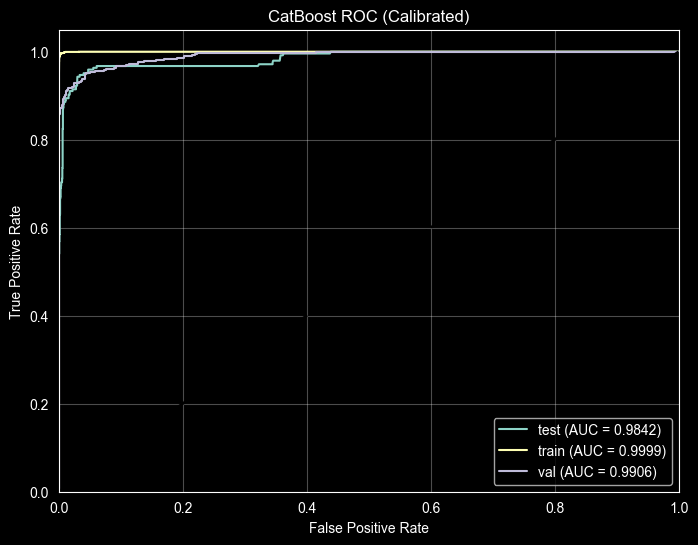

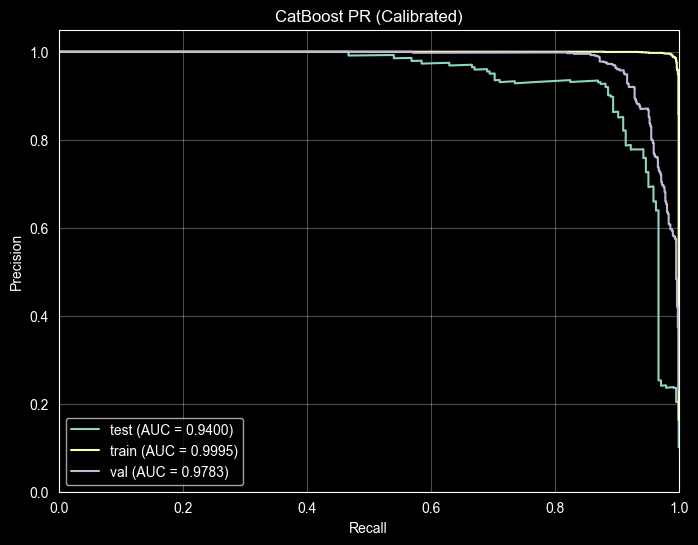

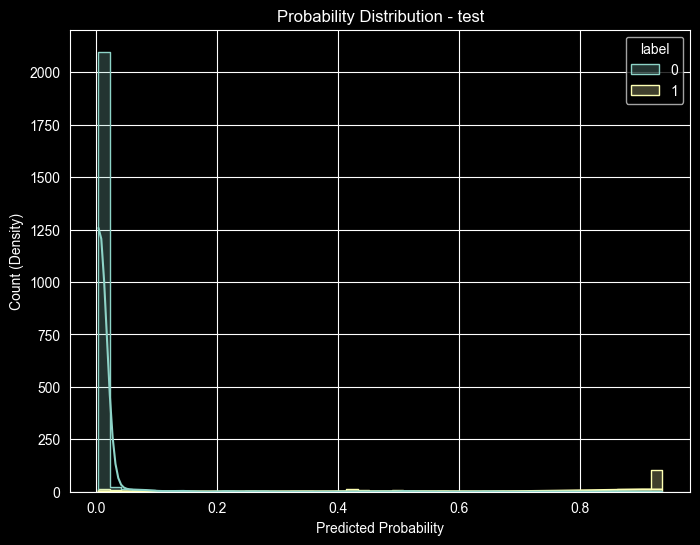

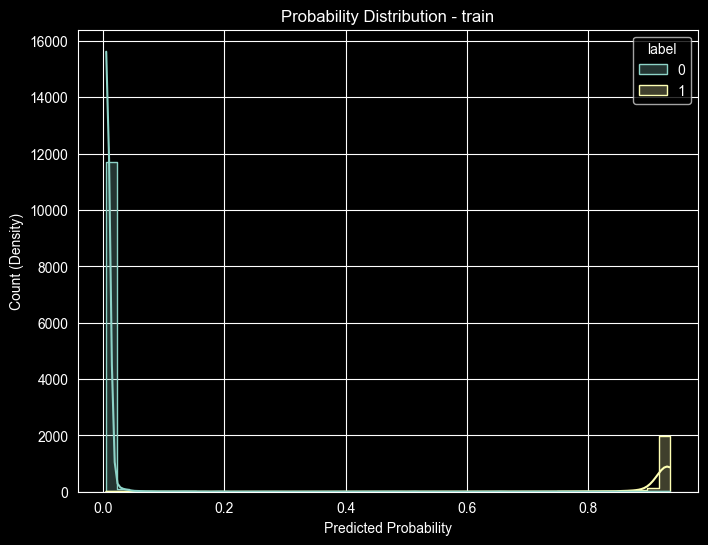

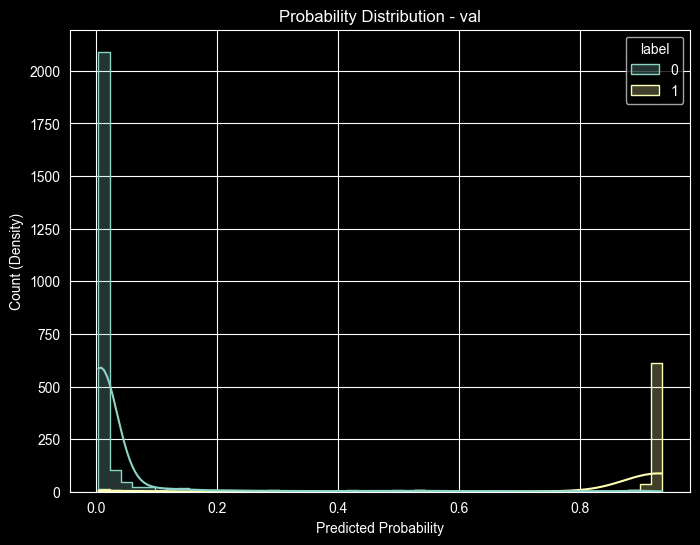


--- Confusion Matrices at Policy Thresholds ---


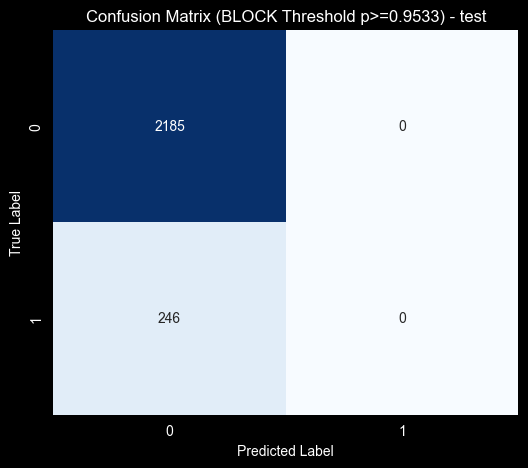

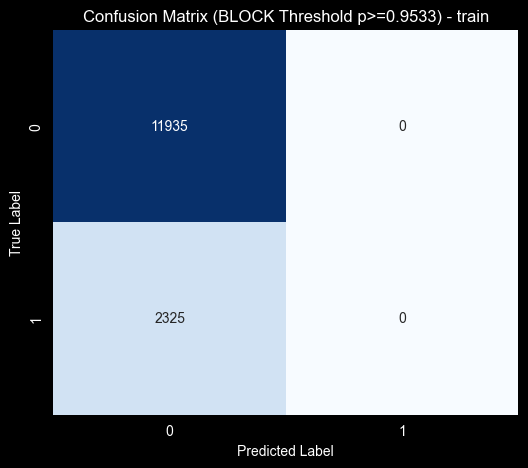

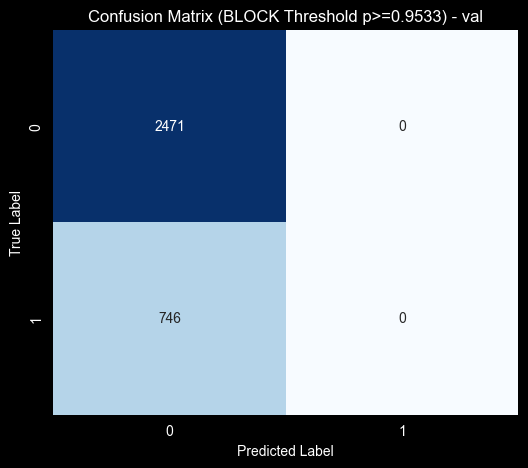

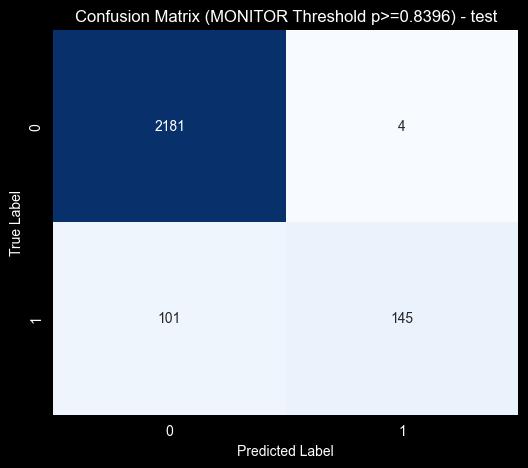

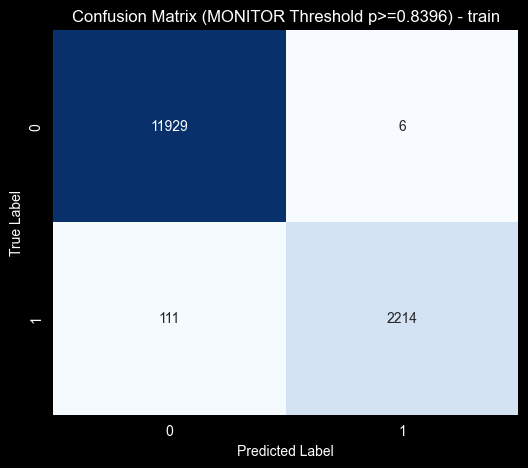

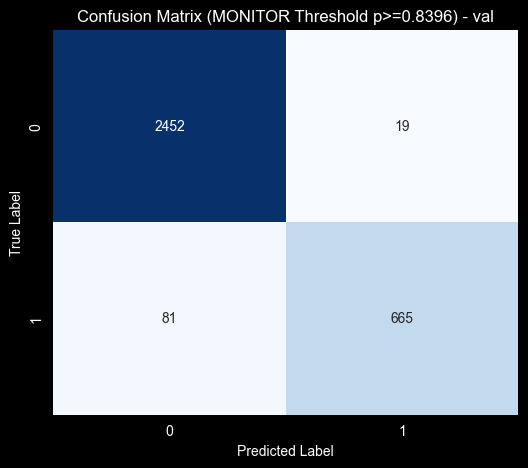

In [5]:
print("\n--- Plots ---")
plot_roc_curves(df_preds, prob_col="p_calib", title="CatBoost ROC (Calibrated)")
plot_pr_curves(df_preds, prob_col="p_calib", title="CatBoost PR (Calibrated)")
plot_probability_distributions(df_preds, prob_col="p_calib")

# REMOVED: plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=0.5)

# NEW: Confusion Matrices for BLOCK and MONITOR thresholds
print("\n--- Confusion Matrices at Policy Thresholds ---")
plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=T_BLOCK, title=f"Confusion Matrix (BLOCK Threshold p>={T_BLOCK:.4f})")
plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=T_MONITOR, title=f"Confusion Matrix (MONITOR Threshold p>={T_MONITOR:.4f})")
